In [1]:
# import standard python packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# load Dan's custom CHIME packages
import calibration as cal

# Calibration process

1. Fit gaussian to sun transiting the CHIME beam

2. Assume standard flux of sun (1 SFU = 10000 Jy) -- the current used value is 49 +/- 8.9 SFU

3. Derive conversion factor from counts to Jy
 - `counts_to_Jy` = flux / height [Jy/cts]
    -  height derived from data
    - flux assumed to be a scalar value 

4. Multiply this factor with the data to convert to Jy

----------------------
Below is the summary log of all the calibrations 

In [2]:
df = pd.read_csv("calibration_log.csv")
df = df[df.fit_success == True]
df

,date,target_freq,target_flux,height,center,width,baseline,sun_projection,fit_success
0,2024_056,410,490000.0,2.639661e+07,1817.148024,12.962662,1.287077e+07,0.515785,True
1,2024_057,410,490000.0,1.872937e+07,1819.617887,12.915378,1.275228e+07,0.521489,True
2,2024_058,410,490000.0,1.724214e+07,1819.617003,13.076639,1.239522e+07,0.527059,True
3,2024_059,410,490000.0,2.869793e+07,1817.565499,12.814123,1.232037e+07,0.532711,True
4,2024_060,410,490000.0,2.291275e+07,1818.107757,13.743389,1.226643e+07,0.538172,True
...,...,...,...,...,...,...,...,...,...
758,2026_084,410,490000.0,2.229820e+07,1921.262490,13.143188,1.213286e+07,0.671114,True
759,2025_155,410,490000.0,8.584541e+07,1025.843580,9.541984,1.262472e+07,0.888164,True
760,2025_078,410,490000.0,2.999220e+07,1924.661104,12.228754,1.257382e+07,0.641365,True
761,2026_063,410,490000.0,1.861161e+07,1931.215976,12.785156,1.200420e+07,0.557876,True


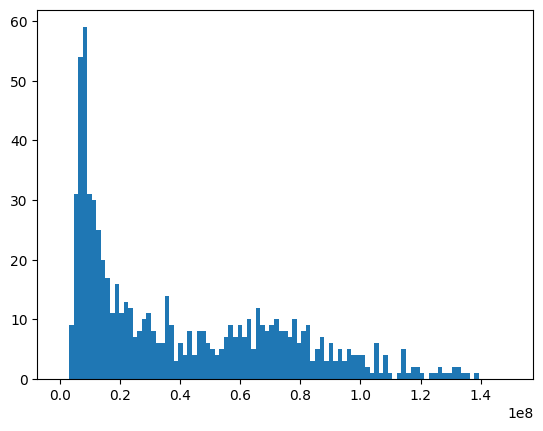

In [3]:
plt.figure()
plt.hist(df.height, bins=np.linspace(0, 1.5e8, num=100))
plt.show()

# What is the resolution of raw CHIME data

Looking at the raw CHIME data, it contains a whole number + 9 decimal places of precision. The solar flux data comes with a resolution of 1 SFU (10000 Jy)

In [4]:
# Load CHIME data in
chime_data, frequency, timestamps = cal.load_CHIME_data("2026_085", unit="MHz")

chime_data.shape

(2854, 1024)

In [5]:
print("Number of decimal places:", len(str(chime_data[0,0]).split(".")[1]))

Number of decimal places: 9


# What is the resolution that could come from the counts and solar flux value? 

Worst case resolution comes from `min(height)` -- fewest steps to cover height of peak. 

For a fixed height value, dFlux = SFV / counts

Thus dFlux = 49 SFU / min(height)

In [6]:
# Loading in calibrated data
cal_df = pd.read_csv("/home/scratch/dbautist/TEST/410/2026_085/2026_085.csv")
cal_df

,instrument,receiver,polarization,intensity_unit,scan_name,scan_datetime,frequency,intensity
0,chime_gbo,chime,I,Jy,2026-03-26,2026-03-26T04:00:04+00:00,400.390625,266106.659
1,chime_gbo,chime,I,Jy,2026-03-26,2026-03-26T04:00:04+00:00,400.781250,306372.582
2,chime_gbo,chime,I,Jy,2026-03-26,2026-03-26T04:00:04+00:00,401.171875,253149.400
3,chime_gbo,chime,I,Jy,2026-03-26,2026-03-26T04:00:04+00:00,401.562500,233284.418
4,chime_gbo,chime,I,Jy,2026-03-26,2026-03-26T04:00:04+00:00,401.953125,196052.858
...,...,...,...,...,...,...,...,...
1019,chime_gbo,chime,I,Jy,2026-03-26,2026-03-26T04:00:04+00:00,798.437500,36953.664
1020,chime_gbo,chime,I,Jy,2026-03-26,2026-03-26T04:00:04+00:00,798.828125,37250.600
1021,chime_gbo,chime,I,Jy,2026-03-26,2026-03-26T04:00:04+00:00,799.218750,37624.408
1022,chime_gbo,chime,I,Jy,2026-03-26,2026-03-26T04:00:04+00:00,799.609375,32866.977


In [7]:
# look at digits from gaussian fit
df.height[1]

18729370.131319888

In [8]:
# worst resolution
dFlux = 49e4/np.min(df.height)

print("The worst resoltion seen in the data is:", dFlux, "Jy/cts")

The worst resoltion seen in the data is: 0.12625335749416486 Jy/cts


In [9]:
# being generous with the flux resolution
print("The best resolution seen in the data is:", 49e4/np.max(df.height), "Jy/cts")

The best resolution seen in the data is: 0.0013808290692754377 Jy/cts


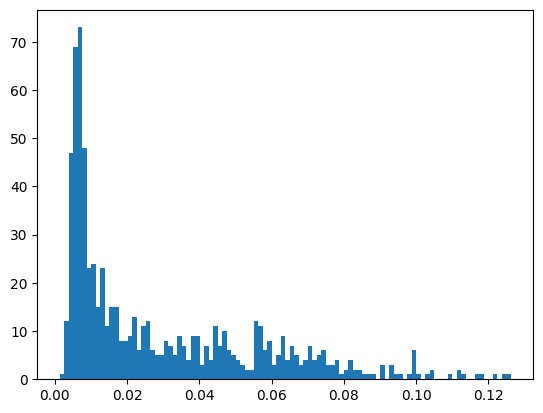

In [10]:
# distribution of flux resolutions

dF = df.target_flux.values / df.height.values

plt.figure()
plt.hist(dF, bins=100)
plt.show()

# Conclusion

Round the calibrated CHIME data to 3 decimal places

In [11]:
test_value = 18729370.131319888

In [12]:
np.round(test_value, decimals=3)

18729370.131

In [13]:
test_arr = np.random.random(10)*100
test_arr

array([36.8961521 , 21.85029541, 42.93653738, 80.33364024, 27.44738821,
        9.38063586, 41.35659519, 85.87847146, 15.02793015, 21.01073227])

In [14]:
np.round(test_arr, decimals=3)

array([36.896, 21.85 , 42.937, 80.334, 27.447,  9.381, 41.357, 85.878,
       15.028, 21.011])